Text(0, 0.5, 'YAP/TAZ N/C')

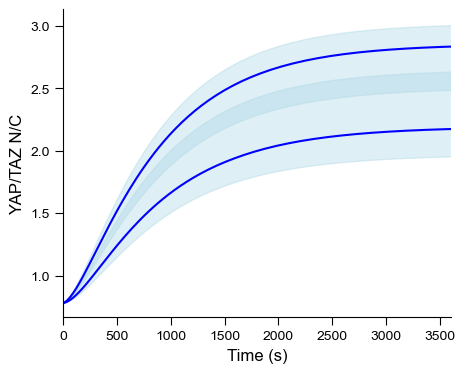

In [75]:
import matplotlib.pyplot as plt
plt.style.use(f"smart_plots.mplstyle")
import numpy as np
highDensitySS = []
lowDensitySS = []
for numCells in [20,50]:
    YAPTAZRatios = np.loadtxt(f"/root/shared/gitrepos/smart-multicell-code/multicell_results_N{numCells}/YAPTAZRatioMat.txt")
    tvec = np.loadtxt(f"/root/shared/gitrepos/smart-multicell-code/multicell_results_N{numCells}/tvec.txt")
    YAPTAZstats = np.zeros((len(tvec),3))
    for i in range(len(tvec)):
        YAPTAZstats[i,:] = np.quantile(YAPTAZRatios[i,:], [0.25,0.5,0.75])
    plt.plot(tvec, YAPTAZstats[:,1], label='Median', color='blue')
    plt.fill_between(tvec, YAPTAZstats[:,0], YAPTAZstats[:,2], color='lightblue', 
                    alpha=0.4, label='Interquartile range')
    highDensitySS.append(YAPTAZRatios[-1,:])

    # YAPTAZRatios = np.loadtxt(f"/root/shared/gitrepos/smart-mechanotransduction/model-files/multicell_results_N{numCells}_lowECMDensity/YAPTAZRatioMat.txt")
    # tvec = np.loadtxt(f"/root/shared/gitrepos/smart-mechanotransduction/model-files/multicell_results_N{numCells}_lowECMDensity/tvec.txt")
    # YAPTAZstats = np.zeros((len(tvec),3))
    # for i in range(len(tvec)):
    #     YAPTAZstats[i,:] = np.quantile(YAPTAZRatios[i,:], [0.25,0.5,0.75])
    # plt.plot(tvec, YAPTAZstats[:,1], label='Median', color='red')
    # plt.fill_between(tvec, YAPTAZstats[:,0], YAPTAZstats[:,2], color=[1.0,0.8,0.8], 
    #                 alpha=0.2, label='Interquartile range')
    # lowDensitySS.append(YAPTAZRatios[-1,:])
plt.xlim([0, 3600])
plt.xlabel('Time (s)')
plt.ylabel('YAP/TAZ N/C')
# plt.savefig('high_density_plots.pdf', format='pdf')

Ttest_indResult(statistic=4.417686669869153, pvalue=3.671115766921185e-05)


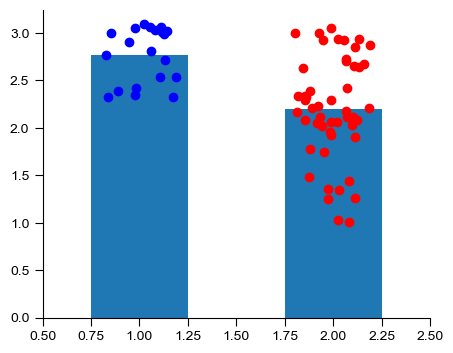

In [76]:
import matplotlib
matplotlib.rcParams.update({'figure.figsize': (5,4)})
seed_value = 42
rng = np.random.default_rng(seed_value)
xvals0 = rng.uniform(low=-0.2, high=0.2, size=(20,))
xvals1 = rng.uniform(low=-0.2, high=0.2, size=(50,))
ssVec = [np.mean(highDensitySS[0]), np.mean(highDensitySS[1])]#,
        #  np.mean(lowDensitySS[0]), np.mean(lowDensitySS[1])]
plt.bar([1,2], ssVec[0:2], width=0.5)
plt.scatter(1+xvals0, highDensitySS[0], color='b')
plt.scatter(2+xvals1, highDensitySS[1], color='r')
# plt.scatter(3+xvals0, lowDensitySS[0])
# plt.scatter(4+xvals1, lowDensitySS[1])
plt.xlim([0.5, 2.5])

from scipy import stats
print(stats.ttest_ind(highDensitySS[0], highDensitySS[1]))

# plt.ylabel('F-actin')
# plt.savefig('factin.pdf', format='pdf')